In [24]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import os
import glob

data_dir = '/Users/harryclark/Downloads/COHORT12/xgboost_task_anchoring'
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

data = pd.DataFrame()
for file in all_files:
    df = pd.read_csv(file)

    if 'X_pos_cov' not in df.columns or 'Y_pos_cov' not in df.columns:
        print(f"Skipping file {file} due to missing columns.")
        continue

    data = pd.concat([data, df], ignore_index=True)

print(f"Loaded {len(all_files)} files. Combined data shape: {data.shape}")

# Calculate difference in X and Y between covariate and test positions
data['delta_X'] = data['X_pos_cov'] - data['X_pos_test']
data['delta_Y'] = data['Y_pos_cov'] - data['Y_pos_test']

Loaded 18 files. Combined data shape: (3634710, 29)


In [26]:
data

,Unnamed: 0,mouse,day,cluster_id,cluster_id_cov,trained_on,tested_on,n_neurons,pR2_cv,cluster_id_theta_index,...,distance,position_in_covariate,cluster_id_grid_score,cluster_id_cov_grid_score,cluster_id_spatial_info,cluster_id_cov_spatial_info,cluster_id_firing_rate_VR,cluster_id_cov_firing_rate_VR,delta_X,delta_Y
0,0,25,21,113,108,GC,ncmGC,0,-0.012621,0.095070,...,30.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-30.0
1,1,25,21,113,108,GC,ncmGC,0,-0.022958,0.095070,...,30.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-30.0
2,2,25,21,113,108,GC,ncmGC,0,-0.011477,0.095070,...,30.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-30.0
3,3,25,21,113,108,GC,ncmGC,0,0.006766,0.095070,...,30.0,True,0.683420,0.534364,0.646268,2.368001,2.396283,1.177237,0.0,-30.0
4,4,25,21,113,108,GC,ncmGC,0,-0.030352,0.095070,...,30.0,True,0.683420,0.534364,0.646268,2.368001,2.396283,1.177237,0.0,-30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3634705,217795,21,25,325,339,NGS,NGS,1,0.034075,0.021838,...,90.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,90.0
3634706,217796,21,25,325,339,NGS,NGS,1,0.033867,0.021838,...,90.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,90.0
3634707,217797,21,25,325,339,NGS,NGS,1,NaN,0.021838,...,90.0,True,NaN,NaN,NaN,NaN,NaN,NaN,0.0,90.0
3634708,217798,21,25,325,339,NGS,NGS,1,NaN,0.021838,...,90.0,True,0.143329,-0.747519,0.129174,0.134033,0.843861,2.683455,0.0,90.0


In [27]:
# Create unique id columns for cluster_id and cluster_id_cov
data['unique_cluster_id'] = (
    data['mouse'].astype(str) + '_' +
    data['day'].astype(str) + '_' +
    data['cluster_id'].astype(str)
)
data['unique_cluster_id_cov'] = (
    data['mouse'].astype(str) + '_' +
    data['day'].astype(str) + '_' +
    data['cluster_id_cov'].astype(str)
)

In [28]:
# Subset to only firing_mode == 'session'
data_session = data[data['firing_mode'] == 'session']

# DataFrame where position_in_covariate is True and n_neurons is 0
position_only = data_session[(data_session['position_in_covariate'] == True) & (data_session['n_neurons'] == 0)]

# DataFrame where position_in_covariate is True and n_neurons is 1
position_single = data_session[(data_session['position_in_covariate'] == True) & (data_session['n_neurons'] == 1)]

neuron_only = data_session[(data_session['position_in_covariate'] == False) & (data_session['n_neurons'] == 1)]

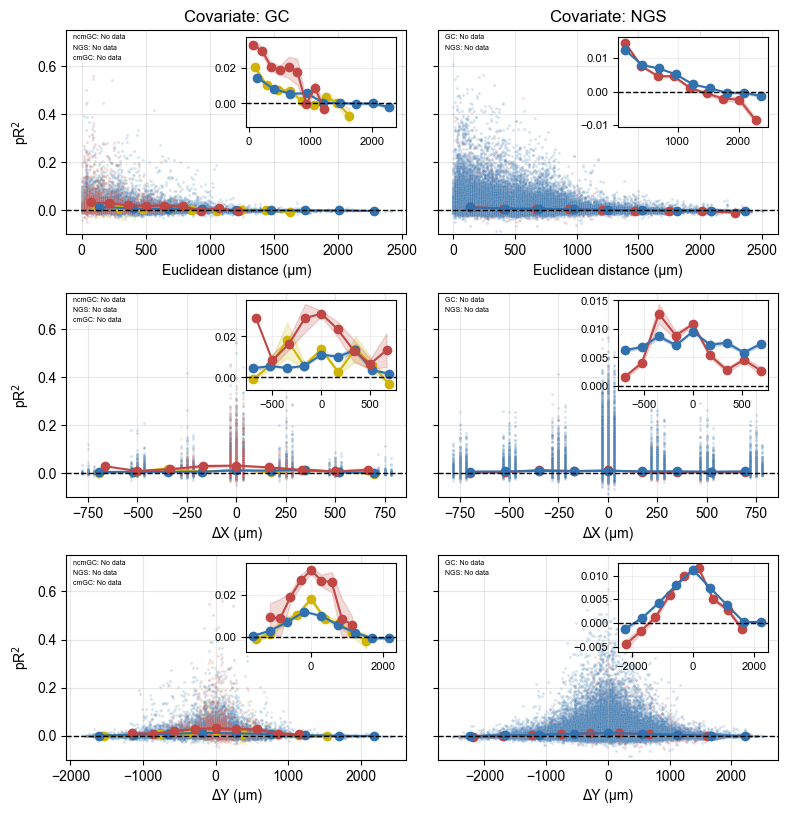

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

do_lmm = False

# Subset to only firing_modes of interest
data_sub = data[data['firing_mode'].isin(['session'])].copy()

x_columns = ['distance', 
             'delta_X', 
             'delta_Y',
             ]
nice_names = {
    'distance': 'Euclidean distance (μm)',
    'delta_X': 'ΔX (μm)',
    'delta_Y': 'ΔY (μm)',
}

tested_on_colors = {
    'ncmGC': "#cfb406",
    'NGS': '#3171ae',
    'cmGC': '#c04744',
    'GC': '#c04744',
    # Add more tested_on groups and colors as needed
}

trained_on_groups = ['GC', 'NGS']

n_rows = len(x_columns)
fig, axes = plt.subplots(n_rows, 2, figsize=(8, 2.8 * n_rows), sharey='row')
if n_rows == 1:
    axes = axes.reshape(1, 2)

for row_idx, x_col in enumerate(x_columns):
    for col_idx, trained_on in enumerate(trained_on_groups):
        ax = axes[row_idx, col_idx]
        data_trained = data_sub[data_sub['trained_on'] == trained_on]
        tested_on_groups = data_trained['tested_on'].unique()
        inset_ax = ax.inset_axes([0.53, 0.525, 0.44, 0.44])

        annotations = []
        for idx, tested_on in enumerate(tested_on_groups):
            df = data_trained[data_trained['tested_on'] == tested_on]
            neuron_only = df[(df['position_in_covariate'] == False) & (df['n_neurons'] == 1)].copy()
            if neuron_only.empty or neuron_only[x_col].isnull().all():
                annotations.append(f"{tested_on}: No data")
                continue

            color = tested_on_colors.get(tested_on, None)
            sns.scatterplot(
                data=neuron_only, x=x_col, y='pR2_cv', alpha=0.2, ax=ax, s=4,
                color=color, legend=False
            )

            bins = np.linspace(neuron_only[x_col].min(), neuron_only[x_col].max(), 10)
            neuron_only[f'{x_col}_bin'] = pd.cut(neuron_only[x_col], bins)
            binned = neuron_only.groupby(f'{x_col}_bin')['pR2_cv'].agg(['mean', 'count', 'std']).reset_index()
            binned['sem'] = binned['std'] / np.sqrt(binned['count'])
            bin_centers = np.array([interval.mid for interval in binned[f'{x_col}_bin']])

            valid = ~binned['mean'].isnull()
            ax.plot(bin_centers[valid], binned['mean'][valid], marker='o', color=color)
            ax.fill_between(bin_centers[valid], binned['mean'][valid] - binned['sem'][valid], binned['mean'][valid] + binned['sem'][valid],
                            color=color, alpha=0.2)
            inset_ax.plot(bin_centers[valid], binned['mean'][valid], marker='o', color=color)
            inset_ax.fill_between(bin_centers[valid], binned['mean'][valid] - binned['sem'][valid], binned['mean'][valid] + binned['sem'][valid],
                                 color=color, alpha=0.2)

            model_data = neuron_only.dropna(subset=[x_col, 'pR2_cv', 'unique_cluster_id', 'unique_cluster_id_cov', 'mouse', 'day'])
            if len(model_data) > 0:
                initial_len = len(model_data)
                model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, 'pR2_cv'])
                dropped = initial_len - len(model_data)
                if dropped > 0:
                    print(f"Dropped {dropped} rows from model_data")

                if do_lmm:
                    formula = f"pR2_cv ~ {x_col}"
                    try:
                        md = smf.mixedlm(
                            formula,
                            model_data,
                            groups=model_data["mouse"],
                            re_formula="~1",
                            vc_formula={
                                "day": "0 + C(day)",
                                "cluster": "0 + C(unique_cluster_id)",
                                "cluster_cov": "0 + C(unique_cluster_id_cov)"
                            }
                        )
                        print(f"Fitting MixedLM for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                        mdf = md.fit(verbose=True)
                        if x_col in mdf.params.index:
                            coef = mdf.params[x_col]
                            pval = mdf.pvalues[x_col]
                            stderr = mdf.bse[x_col]
                            ann = (
                                f"{tested_on}: β={coef:.2f}, SE={stderr:.2f}, p={pval:.2g}, "
                                f"c: {mdf.converged}"
                            )
                            print(f"MixedLM converged for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                        else:
                            ann = f"{tested_on}: not in model, Converged: {mdf.converged}"
                            print(f"MixedLM did not converge for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                    except Exception as e:
                        ann = f"{tested_on}: MixedLM failed: {e}"
                        print(f"MixedLM fitting failed for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}: {e}")
                else:
                    ann = f"{tested_on}: No data"
                annotations.append(ann)

        for i, ann in enumerate(annotations):
            ax.text(
                0.02, 0.98 - i*0.05, ann, ha='left', va='top', fontsize=5, color='k',
                transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

        ax.set_ylim(-0.1, 0.75)
        ax.axhline(0, color='k', linestyle='--', linewidth=1)
        ax.set_xlabel(nice_names.get(x_col, x_col))
        if col_idx == 0:
            ax.set_ylabel('pR$^2$')
        else:
            ax.set_ylabel('')
        if row_idx == 0:
            ax.set_title(f"Covariate: {trained_on}")
        ax.grid(True, alpha=0.3)

        inset_ax.axhline(0, color='k', linestyle='--', linewidth=1)
        inset_ax.tick_params(axis='both', labelsize=8)
        inset_ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/FIGURE3_XGBOOST_single_neuron_ALL_COMBINED_no_pos.pdf", dpi=500)
plt.show()

In [30]:
tmp_subset = data_sub[(data_sub['trained_on'] == 'NGS')
         & (data_sub['tested_on'] == 'GC')
        & (data_sub['position_in_covariate'] == False)
        & (data_sub['n_neurons'] == 1)
        & (data_sub['delta_X'] > -400)
         & (data_sub['delta_X'] < -100)]
print(f'mean pR2_cv for subset: {tmp_subset["pR2_cv"].mean()}')

mean pR2_cv for subset: 0.009804679748717838


In [31]:
top = tmp_subset.sort_values('pR2_cv', ascending=False).head(20)
print(top[['mouse', 'day', 'pR2_cv']])

         mouse  day    pR2_cv
666560      25   25  0.328260
1635890     28   23  0.286357
1633040     28   23  0.268920
666515      25   25  0.230933
663515      25   25  0.229088
653015      25   25  0.192121
3202940     29   23  0.190675
665015      25   25  0.159869
653060      25   25  0.157866
2368115     28   25  0.157351
668000      25   25  0.148171
1630190     28   23  0.147791
2362850     28   25  0.144393
662015      25   25  0.142267
1627340     28   23  0.139474
2380400     28   25  0.129255
668015      25   25  0.121978
668045      25   25  0.111609
663560      25   25  0.107642
675515      25   25  0.107626


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

do_lmm = True

# Subset to only firing_modes of interest
data_sub = data[data['firing_mode'].isin(['session'])].copy()

# Define pairs of columns for each row: (target, covariate)
col_pairs = [
    ('cluster_id_grid_score', 'cluster_id_cov_grid_score'),
    ('cluster_id_theta_index', 'cluster_id_cov_theta_index'),
    ('cluster_id_spatial_info', 'cluster_id_cov_spatial_info'),
    ('cluster_id_firing_rate_VR', 'cluster_id_cov_firing_rate_VR'),
]
nice_names = {
    'cluster_id_grid_score': 'Target cell grid score',
    'cluster_id_theta_index': 'Target cell theta index',
    'cluster_id_spatial_info': 'Target cell spatial info (bits/S)',
    'cluster_id_firing_rate_VR': 'Target cell firing rate (Hz)',
    'cluster_id_cov_grid_score': 'Covariate cell grid score',
    'cluster_id_cov_theta_index': 'Covariate cell theta index',
    'cluster_id_cov_spatial_info': 'Covariate cell spatial info (bits/S)',
    'cluster_id_cov_firing_rate_VR': 'Covariate cell firing rate (Hz)',
}

tested_on_colors = {
    'ncmGC': "#cfb406",
    'NGS': '#3171ae',
    'cmGC': '#c04744',
    'GC': '#c04744',
    # Add more tested_on groups and colors as needed
}

trained_on_groups = ['GC', 'NGS']

n_rows = len(col_pairs)
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 2.8 * n_rows), sharey='row')
if n_rows == 1:
    axes = axes.reshape(1, 4)

for row_idx, (target_col, cov_col) in enumerate(col_pairs):
    for col_idx in range(4):
        # Determine which trained_on and which column to use
        if col_idx < 2:
            trained_on = 'GC'
        else:
            trained_on = 'NGS'
        x_col = target_col if col_idx % 2 == 0 else cov_col

        ax = axes[row_idx, col_idx]
        data_trained = data_sub[data_sub['trained_on'] == trained_on]
        tested_on_groups = data_trained['tested_on'].unique()
        inset_ax = ax.inset_axes([0.53, 0.525, 0.44, 0.44])

        annotations = []
        for idx, tested_on in enumerate(tested_on_groups):
            df = data_trained[data_trained['tested_on'] == tested_on]
            neuron_only = df[(df['position_in_covariate'] == False) & (df['n_neurons'] == 1)].copy()
            if neuron_only.empty or neuron_only[x_col].isnull().all():
                annotations.append(f"{tested_on}: No data")
                continue

            color = tested_on_colors.get(tested_on, None)
            sns.scatterplot(
                data=neuron_only, x=x_col, y='pR2_cv', alpha=0.2, ax=ax, s=4,
                color=color, legend=False
            )

            bins = np.linspace(neuron_only[x_col].min(), neuron_only[x_col].max(), 10)
            neuron_only[f'{x_col}_bin'] = pd.cut(neuron_only[x_col], bins)
            binned = neuron_only.groupby(f'{x_col}_bin')['pR2_cv'].agg(['mean', 'count', 'std']).reset_index()
            binned['sem'] = binned['std'] / np.sqrt(binned['count'])
            bin_centers = np.array([interval.mid for interval in binned[f'{x_col}_bin']])

            valid = ~binned['mean'].isnull()
            ax.plot(bin_centers[valid], binned['mean'][valid], marker='o', color=color)
            ax.fill_between(bin_centers[valid], binned['mean'][valid] - binned['sem'][valid], binned['mean'][valid] + binned['sem'][valid],
                            color=color, alpha=0.2)
            inset_ax.plot(bin_centers[valid], binned['mean'][valid], marker='o', color=color)
            inset_ax.fill_between(bin_centers[valid], binned['mean'][valid] - binned['sem'][valid], binned['mean'][valid] + binned['sem'][valid],
                                 color=color, alpha=0.2)

            model_data = neuron_only.dropna(subset=[x_col, 'pR2_cv', 'unique_cluster_id', 'unique_cluster_id_cov', 'mouse', 'day'])
            if len(model_data) > 0:
                initial_len = len(model_data)
                model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, 'pR2_cv'])
                dropped = initial_len - len(model_data)
                if dropped > 0:
                    print(f"Dropped {dropped} rows from model_data")

                if do_lmm:
                    formula = f"pR2_cv ~ {x_col}"
                    try:
                        md = smf.mixedlm(
                            formula,
                            model_data,
                            groups=model_data["mouse"],
                            re_formula="~1",
                            vc_formula={
                                "day": "0 + C(day)",
                                "cluster": "0 + C(unique_cluster_id)",
                                "cluster_cov": "0 + C(unique_cluster_id_cov)"
                            }
                        )
                        print(f"Fitting MixedLM for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                        mdf = md.fit(verbose=True)
                        if x_col in mdf.params.index:
                            coef = mdf.params[x_col]
                            pval = mdf.pvalues[x_col]
                            stderr = mdf.bse[x_col]
                            ann = (
                                f"{tested_on}: β={coef:.2f}, SE={stderr:.2f}, p={pval:.2g}, "
                                f"c: {mdf.converged}"
                            )
                            print(f"MixedLM converged for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                        else:
                            ann = f"{tested_on}: not in model, Converged: {mdf.converged}"
                            print(f"MixedLM did not converge for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}")
                    except Exception as e:
                        ann = f"{tested_on}: MixedLM failed: {e}"
                        print(f"MixedLM fitting failed for {x_col} | trained_on: {trained_on} | tested_on: {tested_on}: {e}")
                else:
                    ann = f"{tested_on}: No data"
                annotations.append(ann)

        for i, ann in enumerate(annotations):
            ax.text(
                0.02, 0.98 - i*0.05, ann, ha='left', va='top', fontsize=5, color='k',
                transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

        ax.set_ylim(-0.1, 0.75)
        ax.axhline(0, color='k', linestyle='--', linewidth=1)
        ax.set_xlabel(nice_names.get(x_col, x_col))
        if col_idx == 0:
            ax.set_ylabel('pR$^2$')
        else:
            ax.set_ylabel('')
        if row_idx == 0:
            if col_idx < 2:
                ax.set_title(f"GC: Covariate")
            else:
                ax.set_title(f"NGS: Covariate")
        ax.grid(True, alpha=0.3)

        inset_ax.axhline(0, color='k', linestyle='--', linewidth=1)
        inset_ax.tick_params(axis='both', labelsize=8)
        inset_ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/FIGURE3_XGBOOST_single_neuron_GRID_THETA_INFO_FR_TARGET_COVARIATE.pdf", dpi=500)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 2 columns (GC, NGS), 1 row
plot_configs = [
    {'trained_on': 'GC',  'title': 'Covariate: GC'},
    {'trained_on': 'NGS', 'title': 'Covariate: NGS'},
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

def pval_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    # Get both position_in_covariate True and False for this trained_on
    data_true = data[
        (data['firing_mode'].isin(['trainTI_testTA', 'trainTA_testTI'])) &
        (data['n_neurons'] == 1) &
        (data['position_in_covariate'] == True) &
        (data['trained_on'] == config['trained_on'])
    ].copy()
    data_false = data[
        (data['firing_mode'].isin(['trainTI_testTA', 'trainTA_testTI'])) &
        (data['n_neurons'] == 1) &
        (data['position_in_covariate'] == False) &
        (data['trained_on'] == config['trained_on'])
    ].copy()

    data_true['cov_label'] = 'Position in covariate = True'
    data_false['cov_label'] = 'Position in covariate = False'
    plot_data = pd.concat([data_true, data_false], ignore_index=True)

    summary = plot_data.groupby(['tested_on', 'cov_label', 'firing_mode'])['pR2_cv'].agg(['mean', 'sem']).reset_index()
    tested_on_list = summary['tested_on'].unique()
    cov_labels = ['Position in covariate = False', 'Position in covariate = True']
    firing_modes = ['trainTI_testTA', 'trainTA_testTI']
    width = 0.18

    # For each tested_on, plot bars for [False/trainTI, False/trainTA, True/trainTI, True/trainTA]
    bar_positions = []
    bar_means = []
    bar_sems = []
    bar_labels = []
    bar_tested_on = []
    bar_cov_label = []
    bar_firing_mode = []

    for i, tested_on in enumerate(tested_on_list):
        for j, cov_label in enumerate(cov_labels):
            for k, firing_mode in enumerate(firing_modes):
                sub = summary[
                    (summary['tested_on'] == tested_on) &
                    (summary['cov_label'] == cov_label) &
                    (summary['firing_mode'] == firing_mode)
                ]
                mean = sub['mean'].values[0] if not sub.empty else np.nan
                sem = sub['sem'].values[0] if not sub.empty else np.nan
                bar_x = i + (j-0.5)*width*2 + (k-0.5)*width
                color = 'magenta' if firing_mode == 'trainTI_testTA' else 'cyan'
                label = None
                if i == 0:
                    if j == 0 and k == 0:
                        label = 'trainTI_testTA (cov=False)'
                    elif j == 0 and k == 1:
                        label = 'trainTA_testTI (cov=False)'
                    elif j == 1 and k == 0:
                        label = 'trainTI_testTA (cov=True)'
                    elif j == 1 and k == 1:
                        label = 'trainTA_testTI (cov=True)'
                hatch = '///' if cov_label == 'Position in covariate = True' else None
                ax.bar(
                    bar_x, mean, yerr=sem, width=width, color=color, edgecolor='black',
                    capsize=4, alpha=0.8, hatch=hatch, label=label
                )
                # Save for annotation and lines
                bar_positions.append(bar_x)
                bar_means.append(mean)
                bar_sems.append(sem)
                bar_labels.append(label)
                bar_tested_on.append(tested_on)
                bar_cov_label.append(cov_label)
                bar_firing_mode.append(firing_mode)

    # Annotate p-values from mixedlm for each tested_on group (across all bars for that tested_on)
    for i, tested_on in enumerate(tested_on_list):
        for j, cov_label in enumerate(cov_labels):
            group = plot_data[
                (plot_data['tested_on'] == tested_on) &
                (plot_data['cov_label'] == cov_label)
            ].copy()
            # Only use if both firing_modes present
            if group['firing_mode'].nunique() > 1 and len(group) > 10:
                # Add unique_cluster_id columns if not present
                if 'unique_cluster_id' not in group.columns:
                    group['unique_cluster_id'] = (
                        group['mouse'].astype(str) + '_' +
                        group['day'].astype(str) + '_' +
                        group['cluster_id'].astype(str)
                    )
                if 'unique_cluster_id_cov' not in group.columns:
                    group['unique_cluster_id_cov'] = (
                        group['mouse'].astype(str) + '_' +
                        group['day'].astype(str) + '_' +
                        group['cluster_id_cov'].astype(str)
                    )
                model_data = group.dropna(subset=['pR2_cv', 'firing_mode', 'unique_cluster_id', 'unique_cluster_id_cov', 'mouse', 'day'])
                model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['pR2_cv'])
                ann = "n.s."
                if len(model_data) > 10 and model_data['firing_mode'].nunique() > 1:
                    try:
                        md = smf.mixedlm(
                            "pR2_cv ~ firing_mode",
                            model_data,
                            groups=model_data["mouse"],
                            re_formula="~1",
                            vc_formula={
                                "day": "0 + C(day)",
                                "cluster": "0 + C(unique_cluster_id)",
                                "cluster_cov": "0 + C(unique_cluster_id_cov)"
                            }
                        )
                        mdf = md.fit(method='powell', maxiter=5000)
                        if mdf.converged:
                            param = 'firing_mode[T.trainTI_testTA]'
                            if param in mdf.params.index:
                                pval = mdf.pvalues[param]
                                ann = pval_to_stars(pval)
                            else:
                                ann = "n.s."
                        else:
                            ann = "n.s."
                    except Exception as e:
                        ann = "n.s."
                # Find the two bars for this tested_on/cov_label
                bar_idxs = [ii for ii, (to, cl) in enumerate(zip(bar_tested_on, bar_cov_label)) if to == tested_on and cl == cov_label]
                if len(bar_idxs) == 2:
                    x1, x2 = bar_positions[bar_idxs[0]], bar_positions[bar_idxs[1]]
                    y1 = bar_means[bar_idxs[0]] + (bar_sems[bar_idxs[0]] if not np.isnan(bar_sems[bar_idxs[0]]) else 0)
                    y2 = bar_means[bar_idxs[1]] + (bar_sems[bar_idxs[1]] if not np.isnan(bar_sems[bar_idxs[1]]) else 0)
                    y_max = max(y1, y2)
                    # Draw line
                    line_y = y_max + 0.05
                    ax.plot([x1, x1, x2, x2], [line_y, line_y+0.01, line_y+0.01, line_y], color='k', lw=1)
                    # Place annotation
                    x_annot = (x1 + x2) / 2
                    ax.annotate(
                        ann,
                        xy=(x_annot, line_y + 0.012),
                        ha='center', va='bottom', fontsize=13, color='k',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
                    )

    # Set x-ticks in the center of each tested_on group, labels horizontal
    group_centers = np.arange(len(tested_on_list))
    ax.set_xticks(group_centers)
    ax.set_xticklabels(tested_on_list, rotation=0, ha='center')
    ax.set_title(config['title'])
    if idx == 0:
        ax.set_ylabel('Mean pR$^2$')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('Target cell')

# Only show legend on the rightmost plot, outside the axes
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, fontsize=8, frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5), title=None)

plt.tight_layout()
plt.savefig(f"/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/FIGURE5_taskanchoring.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plot_configs = [
    {'trained_on': 'GC',  'title': 'Covariate: GC'},
    {'trained_on': 'NGS', 'title': 'Covariate: NGS'},
]

# Define a color palette for tested_on groups
tested_on_colors = {
    'ncmGC': "#cfb406",
    'NGS': '#3171ae',
    'cmGC': '#c04744',
    'GC': '#c04744',
    # Add more tested_on groups and colors as needed
}
default_color = "#888888"

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    # Subset for this trained_on group
    df = data[
        (data['trained_on'] == config['trained_on']) &
        (data['n_neurons'] == 1) &
        (data['firing_mode'].isin(['trainTI_testTA', 'trainTA_testTI']))
    ].copy()

    # Pivot so each row is a unique cell (mouse, day, cluster_id, tested_on, cov_label), columns are firing_mode
    df['cov_label'] = np.where(df['position_in_covariate'], 'Position in covariate = True', 'Position in covariate = False')
    pivot_cols = ['mouse', 'day', 'cluster_id', 'tested_on', 'cov_label']
    df_pivot = df.pivot_table(index=pivot_cols, columns='firing_mode', values='pR2_cv').reset_index()

    # Drop rows with missing values (i.e., must have both firing_modes)
    df_pivot = df_pivot.dropna(subset=['trainTI_testTA', 'trainTA_testTI'])

    # Get unique tested_on groups for legend
    tested_on_groups = df_pivot['tested_on'].unique()

    for tested_on in tested_on_groups:
        mask = df_pivot['tested_on'] == tested_on
        color = tested_on_colors.get(tested_on, default_color)
        ax.scatter(
            df_pivot.loc[mask, 'trainTI_testTA'],
            df_pivot.loc[mask, 'trainTA_testTI'],
            alpha=0.3, s=30, color=color, label=tested_on
        )

    # Diagonal line for reference
    lims = [
        np.nanmin([df_pivot['trainTI_testTA'].min(), df_pivot['trainTA_testTI'].min()]),
        np.nanmax([df_pivot['trainTI_testTA'].max(), df_pivot['trainTA_testTI'].max()])
    ]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel('pR$^2$ (train on TI, test on TA)')
    if idx == 0:
        ax.set_ylabel('pR$^2$ (train on TA, test on TI)')
    else:
        ax.set_ylabel('')
    ax.set_title(config['title'])
    ax.set_xlim(-0.2,0.4)
    ax.set_ylim(-0.2,0.4)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig(f"/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/FIGURE5_taskanchoring_scatter.png", dpi=300)
plt.show()